# 1. Training and Test Data

In [ ]:
import numpy as np

from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA

# Loading processed data
# Using full path

data_path = "/Users/alextran/Documents/171/Project"

X_train = np.load(data_path + "/Training/X_train.npy")

X_test = np.load(data_path + "/Testing/X_test.npy")

y_train = np.load(data_path + "/Training/y_train.npy")

y_test = np.load(data_path + "/Testing/y_test.npy")

print(X_train.shape)

# Flattening the 3D spectrogram

X_train = X_train.reshape(X_train.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape)

# Label encoding
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)

y_test_enc = le.transform(y_test)


(793, 128, 1292)
(793, 165376)


# 2. Training Setup (Random Forest)

In [52]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import f1_score

# n_estimators=100 is a standard baseline
# n_jobs=-1 allows the model to use all CPU cores (highly recommended for RF)

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fitting model on training data by flattening X_train

rf_baseline.fit(X_train, y_train_enc)

# Setting predictions

y_pred_enc = rf_baseline.predict(X_test)

# Converting the labels to genre names for comparison
y_pred_labels = le.inverse_transform(y_pred_enc)

# Analysis measurement
f1 = f1_score(y_test, y_pred_labels, average='macro')

print(f"Baseline Random Forest F1 Score: {f1}")

Baseline Random Forest F1 Score: 0.39711338171363597


# 3. Hyperparameter Tuning
- BayesSearchCV to optimize the Random Forest.
- Using max_depth and min_samples_split to manage overfitting.
- They control how complex each individual tree can get in the dataset.

In [ ]:
from skopt import BayesSearchCV

from skopt.space import Integer, Categorical

# Reinitializing

rf = RandomForestClassifier(random_state=42)

# Setting the search space based on audio classification
search_space = {"n_estimators": Integer(100, 200),         # Number of trees = n_estimators

    "max_depth": Integer(10, 25),              # Controls overfitting limiting height, how tall the tree is = max_depth to limit overfitting

    "min_samples_split": Integer(2, 10),       # Minimum samples to split node

    "max_features": Categorical(['sqrt', 'log2']), # Number of features in each split
}

# Bayesian Search
bayes_search_rf = BayesSearchCV(
    estimator=rf, search_spaces=search_space, scoring="f1_macro", n_iter=15,     # 15 iterations for Random Forest to maintain a balance
    
    cv=5,          # 5-folds

    n_jobs=1,

    random_state=42,

    verbose=2
)

# Finding the best parameters

bayes_search_rf.fit(X_train, y_train_enc)


print("Overall Best Parameters (Random Forest):")

print(bayes_search_rf.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END max_depth=16, max_features=log2, min_samples_split=9, n_estimators=132; total time=   2.2s
[CV] END max_depth=16, max_features=log2, min_samples_split=9, n_estimators=132; total time=   1.1s
[CV] END max_depth=16, max_features=log2, min_samples_split=9, n_estimators=132; total time=   0.7s
[CV] END max_depth=16, max_features=log2, min_samples_split=9, n_estimators=132; total time=   1.8s
[CV] END max_depth=16, max_features=log2, min_samples_split=9, n_estimators=132; total time=   1.2s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END max_depth=23, max_features=log2, min_samples_split=4, n_estimators=195; total time=   1.7s
[CV] END max_depth=23, max_features=log2, min_samples_split=4, n_estimators=195; total time=   1.4s
[CV] END max_depth=23, max_features=log2, min_samples_split=4, n_estimators=195; total time=   1.1s
[CV] END max_depth=23, max_features=log2, min_samples_split=4, n_estimators=195; t

# 4. Evaluate Tuned Model on Test Set

In [55]:
# Retrain with best parameters found by BayesSearchCV
best_rf = RandomForestClassifier(**bayes_search_rf.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train_enc)
y_pred_tuned = le.inverse_transform(best_rf.predict(X_test))
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

In [56]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# model comparison
print("\n" + "="*70)
print("MODEL COMPARISON (Macro F1)")
print("="*70)
print(f"Baseline RF:        {f1:.4f}")
print(f"Tuned RF:           {f1_tuned:.4f}  (CV best: {bayes_search_rf.best_score_:.4f})")

# summary metrics
print("="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(f"\nBest Hyperparameters: {bayes_search_rf.best_params_}")
print(f"Best Cross-Validation F1 Score: {bayes_search_rf.best_score_:.4f}")
print(f"\nTest Set Accuracy:          {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Test Set F1 Score (Macro):  {f1_tuned:.4f}")
print(f"Test Set Precision (Macro): {precision_score(y_test, y_pred_tuned, average='macro'):.4f}")
print(f"Test Set Recall (Macro):    {recall_score(y_test, y_pred_tuned, average='macro'):.4f}")

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_tuned))


MODEL COMPARISON (Macro F1)
Baseline RF:        0.3971
Tuned RF:           0.4284  (CV best: 0.4844)
MODEL PERFORMANCE

Best Hyperparameters: OrderedDict([('max_depth', 11), ('max_features', 'sqrt'), ('min_samples_split', 3), ('n_estimators', 163)])
Best Cross-Validation F1 Score: 0.4844

Test Set Accuracy:          0.4444
Test Set F1 Score (Macro):  0.4284
Test Set Precision (Macro): 0.4375
Test Set Recall (Macro):    0.4447

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues       0.38      0.25      0.30        20
   classical       0.74      0.74      0.74        19
     country       0.41      0.45      0.43        20
       disco       0.29      0.30      0.29        20
      hiphop       0.42      0.40      0.41        20
        jazz       0.40      0.20      0.27        20
       metal       0.70      0.80      0.74        20
         pop       0.40      0.80      0.53        20
      reggae       0.38      0.30      0.33        20
     

# Performance Analysis by Genre

PER-GENRE PERFORMANCE METRICS
           precision    recall  f1-score  support
blues       0.384615  0.250000  0.303030     20.0
classical   0.736842  0.736842  0.736842     19.0
country     0.409091  0.450000  0.428571     20.0
disco       0.285714  0.300000  0.292683     20.0
hiphop      0.421053  0.400000  0.410256     20.0
jazz        0.400000  0.200000  0.266667     20.0
metal       0.695652  0.800000  0.744186     20.0
pop         0.400000  0.800000  0.533333     20.0
reggae      0.375000  0.300000  0.333333     20.0
rock        0.266667  0.210526  0.235294     19.0


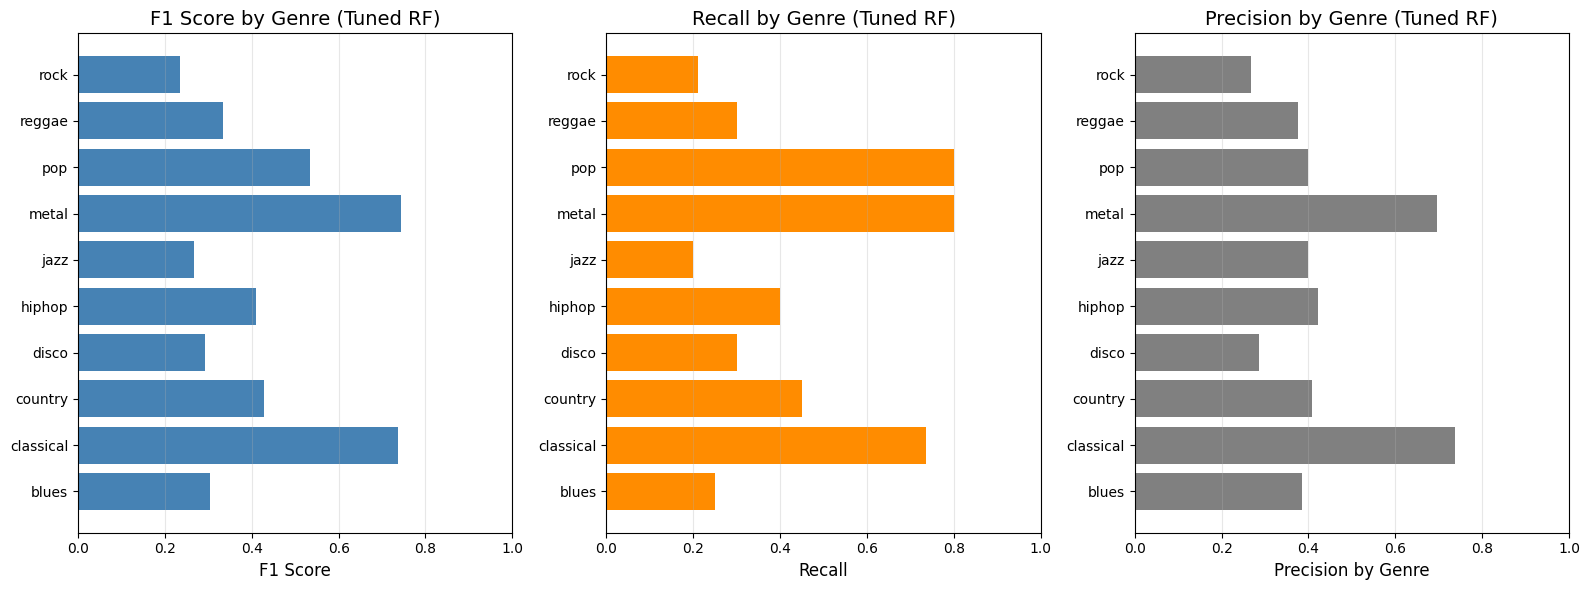

In [57]:
# Extract F1 and Recall per-genre
report = classification_report(y_test, y_pred_tuned, output_dict=True)
genres = sorted(np.unique(y_test))
f1_scores = [report[genre]['f1-score'] for genre in genres]
recall_scores = [report[genre]['recall'] for genre in genres]
precision_scores = [report[genre]['precision'] for genre in genres]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

# Convert to DataFrame for better visualization
df_report = pd.DataFrame(report).transpose()

# Display genre-level metrics
print("="*70)
print("PER-GENRE PERFORMANCE METRICS")
print("="*70)
print(df_report.head(len(genres)))

# Bar hart for F1
ax1.barh(genres, f1_scores, color='steelblue')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('F1 Score by Genre (Tuned RF)', fontsize=14)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Bar chart for recall
ax2.barh(genres, recall_scores, color='darkorange')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_title('Recall by Genre (Tuned RF)', fontsize=14)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

# Bar chart for recall
ax3.barh(genres, precision_scores, color='gray')
ax3.set_xlabel('Precision by Genre', fontsize=12)
ax3.set_title('Precision by Genre (Tuned RF)', fontsize=14)
ax3.set_xlim(0, 1)
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
# function for computing number of songs predicted across all genres for the positive genre
def plot_prediction_frequency(target_genre):
    rates = []
    for g in genres:
        subset = y_pred_tuned[y_test == g]
        rate = np.mean(subset == target_genre)
        rates.append(rate)
    
    sns.barplot(x=genres, y=rates)
    plt.xticks(rotation=45)
    plt.ylabel(f"Proportion Predicted as {target_genre.capitalize()}")
    plt.xlabel("True Genre")
    plt.title(f"Frequency of {target_genre.capitalize()} Predictions by True Genre")
    plt.tight_layout()
    plt.show()

# Classical
- High F1 Score, recall, and precision
- model likely finds strong splitting features due to spectral distinctness
- Best performing genre

# Pop
- Amazing recall but average precision leading to good F1 score
- Accurately classified but overclassified
- Pop's spectral features likely overlap with other genres, leading to many false positives lowering precision

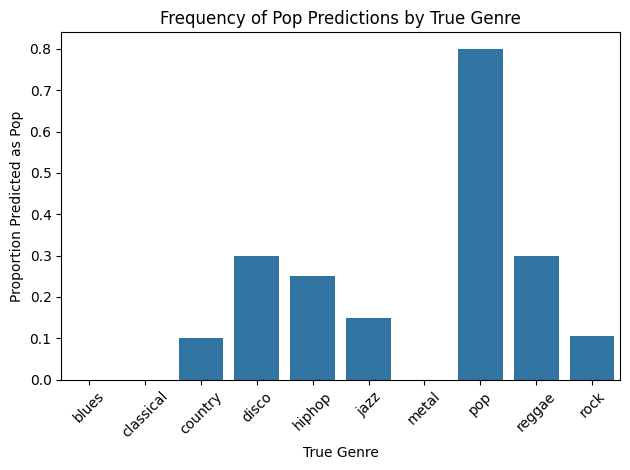

In [ ]:
plot_prediction_frequency("pop")

# Metal
- Great F1 Score and recall, and good precision
- Good results can likely be attributed to spectral distinctness

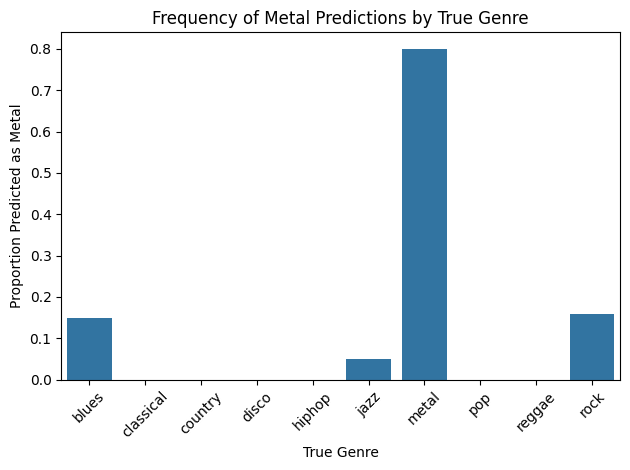

In [60]:
plot_prediction_frequency("metal")

# Reggae, Hip Hop, Country
- Mediocre F1, recall, and precision

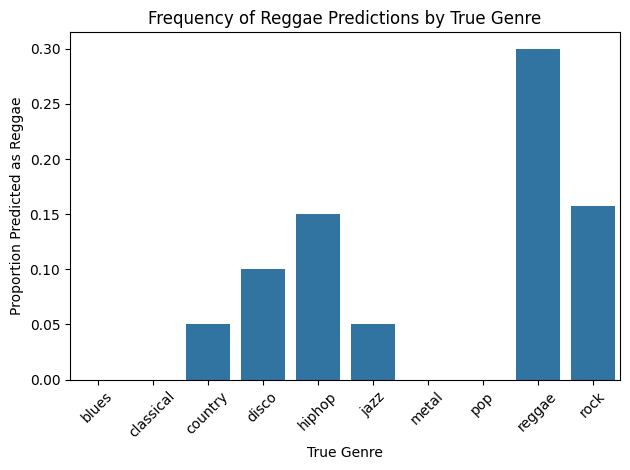

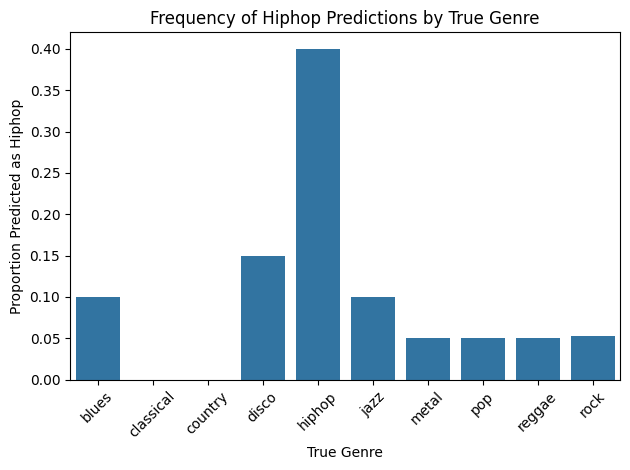

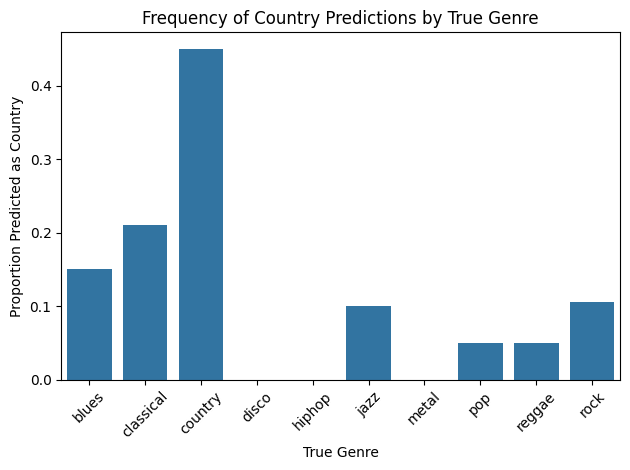

In [61]:
plot_prediction_frequency("reggae")
plot_prediction_frequency("hiphop")
plot_prediction_frequency("country")

# Disco, Rock, Jazz, Blues
- below average F1, recall, and precision (slightly worse than previous 3 genres)

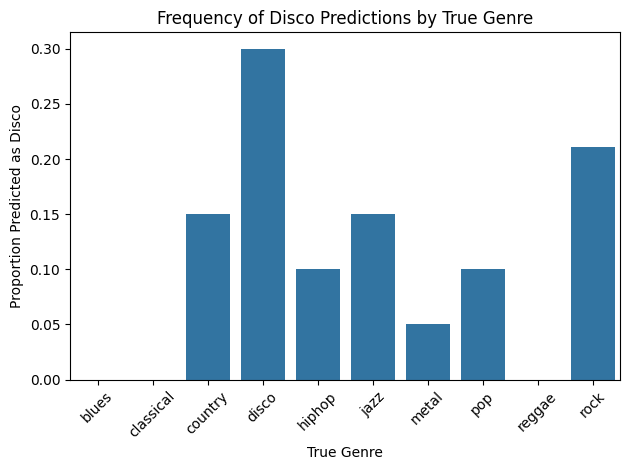

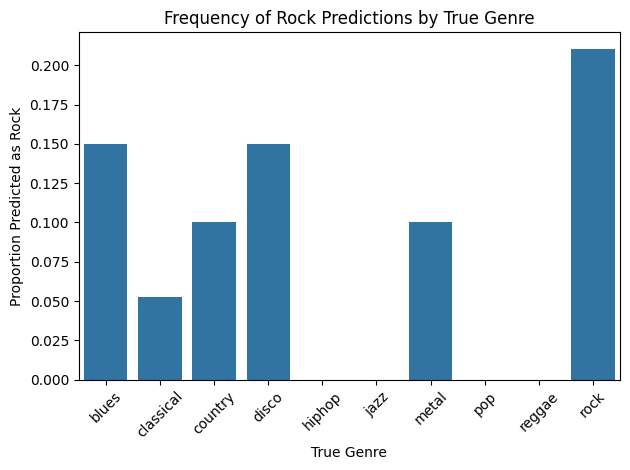

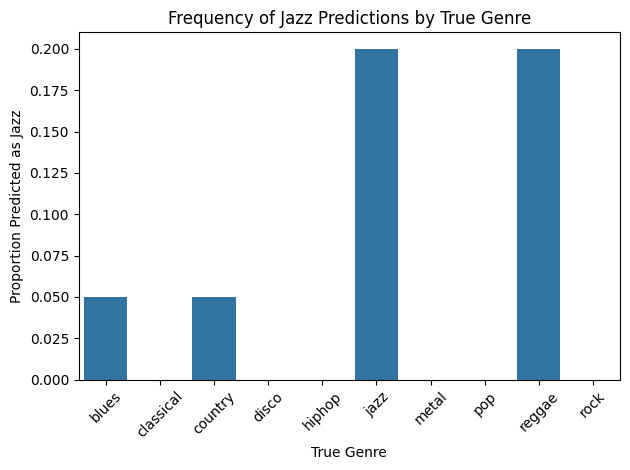

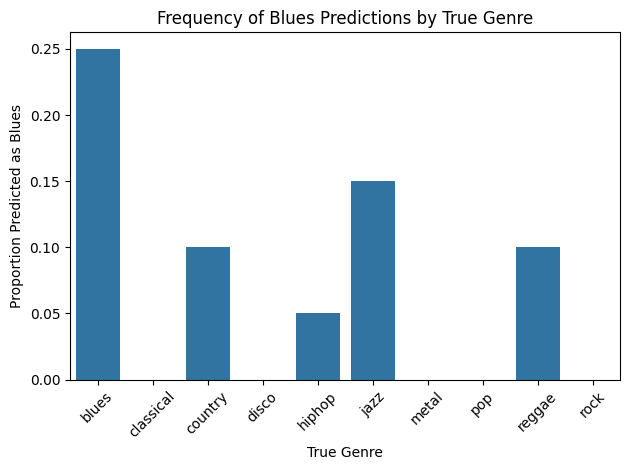

In [62]:
plot_prediction_frequency("disco")
plot_prediction_frequency("rock")
plot_prediction_frequency("jazz")
plot_prediction_frequency("blues")